In [1]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image
from pathlib import Path

/usr/local/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import torch
torch.cuda.empty_cache()


In [3]:
from pathlib import Path

base_dir = Path("Datasets")
positive_dir = base_dir / "Positive"
negative_dir = base_dir / "Negative"



In [4]:
print("Positive images found:", len(list(positive_dir.glob("*.jpg"))))
print("Negative images found:", len(list(negative_dir.glob("*.jpg"))))


Positive images found: 145
Negative images found: 691


In [5]:
# Custom Dataset class to handle images and labels
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = 1 if self.dataframe.iloc[idx, 1] == "POSITIVE" else 0
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
def generate_df(image_dir, label):
    filepaths = pd.Series(list(image_dir.glob(r'*.jpg')), name='Filepath', dtype='string')
    labels = pd.Series(label, name='Label', index=filepaths.index)
    df = pd.concat([filepaths, labels], axis=1)
    return df


In [7]:
# Generate dataframes for positive and negative images
positive_df = generate_df(positive_dir, label="POSITIVE")
negative_df = generate_df(negative_dir, label="NEGATIVE")
all_df = pd.concat([positive_df, negative_df], axis=0).sample(frac=1.0, random_state=1).reset_index(drop=True)
all_df

,Filepath,Label
0,Datasets/Negative/part_12_9.jpg,NEGATIVE
1,Datasets/Negative/part_8_2.jpg,NEGATIVE
2,Datasets/Negative/part_15_11 (2).jpg,NEGATIVE
3,Datasets/Negative/part_6_17.jpg,NEGATIVE
4,Datasets/Negative/part_10_8.jpg,NEGATIVE
...,...,...
831,Datasets/Negative/part_8_7 (2).jpg,NEGATIVE
832,Datasets/Negative/part_18_19.jpg,NEGATIVE
833,Datasets/Positive/part_7_0 - Copy.jpg,POSITIVE
834,Datasets/Negative/part_12_1.jpg,NEGATIVE


In [8]:
# Split the data into training+validation and test sets (20% for testing)
train_val_df, test_df = train_test_split(all_df, test_size=0.20, stratify=all_df['Label'], random_state=42)

In [9]:
# Split training+validation set into training and validation sets (15% of the total data for validation)
train_df, val_df = train_test_split(train_val_df, test_size=0.176, stratify=train_val_df['Label'], random_state=42)

In [10]:
# Display the sizes of the datasets
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 550
Validation set size: 118
Test set size: 168


In [11]:
# Set batch size
batch_size = 16

# Define transformations for training and validation/test sets
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [12]:
# Create datasets
train_dataset = ImageDataset(train_df, transform=train_transform)
val_dataset = ImageDataset(val_df, transform=val_test_transform)
test_dataset = ImageDataset(test_df, transform=val_test_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [13]:
for images, labels in train_loader:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels: {labels}")
    break

Batch of images shape: torch.Size([16, 3, 224, 224])
Batch of labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0])


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvolutionalTokenEmbedding(nn.Module):
    def __init__(self, in_channels, embed_dim, patch_size):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.conv(x)  # Convolutional embedding
        x = x.flatten(2).transpose(1, 2)  # Flatten and rearrange dimensions
        return x

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.WQ = nn.Linear(embed_dim, embed_dim, bias=False)
        self.WK = nn.Linear(embed_dim, embed_dim, bias=False)
        self.WV = nn.Linear(embed_dim, embed_dim, bias=False)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, N, C = x.shape
        Q = self.WQ(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.WK(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.WV(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        attn_weights = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        attn_weights = F.softmax(attn_weights, dim=-1)
        attn_output = torch.matmul(attn_weights, V)

        attn_output = attn_output.transpose(1, 2).reshape(B, N, C)
        return x + self.out_proj(attn_output)  # Residual connection

class FeedForward(nn.Module):
    def __init__(self, embed_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)

    def forward(self, x):
        return x + self.fc2(F.relu(self.fc1(x)))  # Residual FFN

class CVTLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, hidden_dim):
        super().__init__()
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = FeedForward(embed_dim, hidden_dim)

    def forward(self, x):
        x = self.attn(x)
        x = self.ffn(x)
        return x

class DepthwiseResidualProjection(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.depthwise_conv = nn.Conv2d(embed_dim, embed_dim, kernel_size=3, padding=1, groups=embed_dim)

    def forward(self, x):
        return x + self.depthwise_conv(x)  # Depthwise residual connection

class RVT_ResidualOnly(nn.Module):
    def __init__(self, in_channels, embed_dim, patch_size, num_heads, hidden_dim, num_classes):
        super().__init__()
        self.embedding = ConvolutionalTokenEmbedding(in_channels, embed_dim, patch_size)

        self.cvt1 = CVTLayer(embed_dim, num_heads, hidden_dim)
        self.cvt2 = CVTLayer(embed_dim, num_heads, hidden_dim)
        self.cvt3 = CVTLayer(embed_dim, num_heads, hidden_dim)

        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        x = self.embedding(x)
        x1 = self.cvt1(x)
        x2 = self.cvt2(x + x1)
        x3 = self.cvt3(x2 + x1)
        x3 = x3.mean(dim=1)
        return self.classifier(x3)


In [ ]:
import os 
os.environ["CUDA_VISIBLE_DEVICES"] = "0,2"

# Set device to the first visible GPU (index 0 from this list)
device = torch.device("cuda:0")

In [16]:
# # Define the device (GPU/CPU)
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

In [20]:
# Initialize the Residual Vision Transformer (RVT) model
model = RVT_ResidualOnly(
    in_channels=3, embed_dim=64, patch_size=4, num_heads=8, hidden_dim=128, num_classes=2
)


In [21]:
# Wrap it for DataParallel
model = nn.DataParallel(model)

In [22]:
from torchsummary import summary

model.to(device)
print(model)

summary(model, input_size=(3, 224, 224))  


DataParallel(
  (module): RVT_ResidualOnly(
    (embedding): ConvolutionalTokenEmbedding(
      (conv): Conv2d(3, 64, kernel_size=(4, 4), stride=(4, 4))
    )
    (cvt1): CVTLayer(
      (attn): MultiHeadSelfAttention(
        (WQ): Linear(in_features=64, out_features=64, bias=False)
        (WK): Linear(in_features=64, out_features=64, bias=False)
        (WV): Linear(in_features=64, out_features=64, bias=False)
        (out_proj): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): FeedForward(
        (fc1): Linear(in_features=64, out_features=128, bias=True)
        (fc2): Linear(in_features=128, out_features=64, bias=True)
      )
    )
    (cvt2): CVTLayer(
      (attn): MultiHeadSelfAttention(
        (WQ): Linear(in_features=64, out_features=64, bias=False)
        (WK): Linear(in_features=64, out_features=64, bias=False)
        (WV): Linear(in_features=64, out_features=64, bias=False)
        (out_proj): Linear(in_features=64, out_features=64, bias=True)
 

In [23]:
import torch

print(f"{'GPU':<10}{'Allocated (MB)':<20}{'Reserved (MB)':<20}")
for i in range(torch.cuda.device_count()):
    allocated = torch.cuda.memory_allocated(i) / 1024**2
    reserved = torch.cuda.memory_reserved(i) / 1024**2
    print(f"{i:<10}{allocated:<20.2f}{reserved:<20.2f}")


GPU       Allocated (MB)      Reserved (MB)       
0         8.52                1250.00             
1         8.12                1252.00             


In [24]:
# If model is wrapped in DataParallel, get the actual model
if isinstance(model, torch.nn.DataParallel):
    base_model = model.module
else:
    base_model = model

# Count params properly
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params: {total:,}")
    print(f"Trainable params: {trainable:,}")
    print(f"Non-trainable params: {total - trainable:,}")

count_params(base_model)


Total params: 102,466
Trainable params: 102,466
Non-trainable params: 0


In [25]:
# Define the loss function and the optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=5e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [26]:
import torch
from tqdm import tqdm

epochs = 100
patience = 7
counter = 0
best_val_loss = float('inf')

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    print(f'Epoch {epoch+1}/{epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Set model to training mode
            dataloader = train_loader
        else:
            model.eval()   # Set model to evaluation mode
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(dataloader, desc=f'{phase.capitalize()} Batches', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data).item()  # Convert tensor to Python int

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = torch.tensor(running_corrects, dtype=torch.float32) / len(dataloader.dataset)

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accuracies.append(epoch_acc.item())
            scheduler.step()

        else:
            val_losses.append(epoch_loss)
            val_accuracies.append(epoch_acc.item())

            # Early Stopping Check
            if epoch_loss < best_val_loss:
                best_val_loss = epoch_loss
                counter = 0  # Reset counter when improvement is seen
                torch.save(model.state_dict(), 'best_model.pth')  # Save the best model
            else:
                counter += 1  # Increase counter when no improvement

            if counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                model.load_state_dict(torch.load('best_model.pth'))  # Load best model
                break  # Stop training

    if counter >= patience:
        break  

print('Training complete.')


Epoch 1/100
----------


Train Loss: 0.4667 Acc: 0.8164


Val Loss: 0.4007 Acc: 0.8475
Epoch 2/100
----------


Train Loss: 0.4146 Acc: 0.8436


Val Loss: 0.3588 Acc: 0.8475
Epoch 3/100
----------


...

Val Loss: 0.1015 Acc: 0.9492
Epoch 38/100
----------


Train Loss: 0.1459 Acc: 0.9400


Val Loss: 0.0986 Acc: 0.9492
Epoch 39/100
----------


Train Loss: 0.1375 Acc: 0.9473


Val Loss: 0.0984 Acc: 0.9492
Early stopping triggered after 39 epochs.
Training complete.


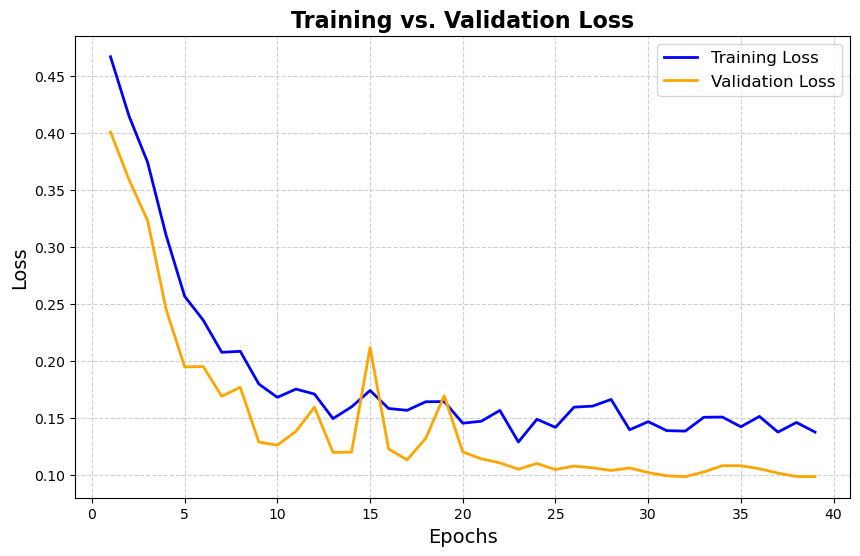

In [27]:
epochs = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label="Training Loss", color="blue", linestyle="-", linewidth=2)
plt.plot(epochs, val_losses, label="Validation Loss", color="orange", linestyle="-", linewidth=2)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.title("Training vs. Validation Loss", fontsize=16, fontweight="bold")
plt.legend(fontsize=12, loc="upper right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

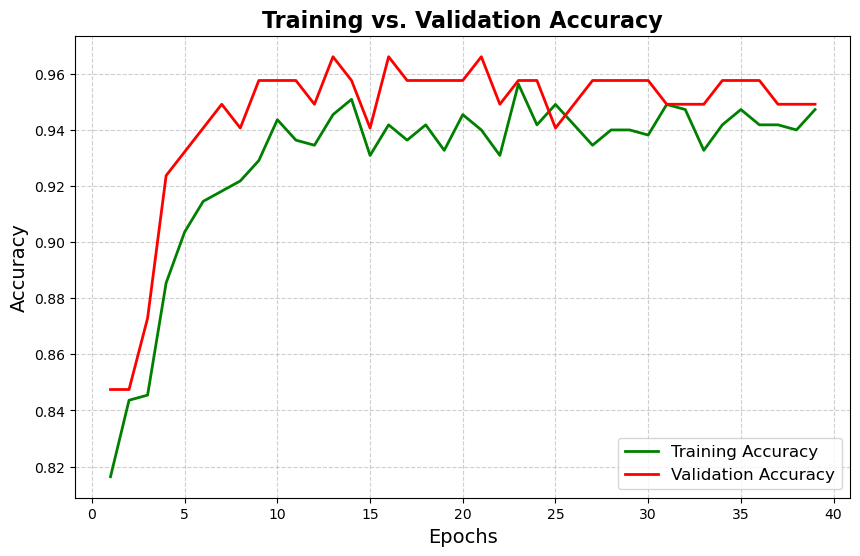

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracies, label="Training Accuracy", color="green", linestyle="-", linewidth=2)
plt.plot(epochs, val_accuracies, label="Validation Accuracy", color="red", linestyle="-", linewidth=2)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Training vs. Validation Accuracy", fontsize=16, fontweight="bold")
plt.legend(fontsize=12, loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [32]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Set the model to evaluation mode
model.eval()

test_loss = 0.0
total = 0
correct = 0
y_true = []
y_pred = []
y_prob = [] 

# Disable gradient calculation for evaluation
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        # Calculate loss for the batch
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)

        # Get predicted classes and probabilities
        probs = torch.softmax(outputs, dim=1)  # Convert logits to probabilities
        _, predicted = torch.max(probs, 1)

        # Store values
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob.extend(probs[:, 1].cpu().numpy())  # Probabilities for class 1

# Compute average loss and accuracy
test_loss /= total
test_acc = correct / total
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Classification metrics
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", conf_matrix)

class_report = classification_report(y_true, y_pred, target_names=["NEGATIVE", "POSITIVE"])
print("Classification Report:\n", class_report)

Test Loss: 0.1666, Test Accuracy: 0.9345
Confusion Matrix:
 [[136   3]
 [  8  21]]
Classification Report:
               precision    recall  f1-score   support

    NEGATIVE       0.94      0.98      0.96       139
    POSITIVE       0.88      0.72      0.79        29

    accuracy                           0.93       168
   macro avg       0.91      0.85      0.88       168
weighted avg       0.93      0.93      0.93       168



AUC Score: 0.9773


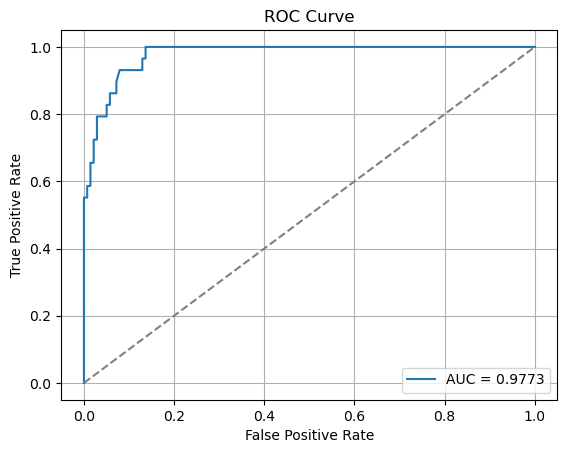

In [33]:
# AUC and ROC Curve
auc = roc_auc_score(y_true, y_prob)
print(f"AUC Score: {auc:.4f}")

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

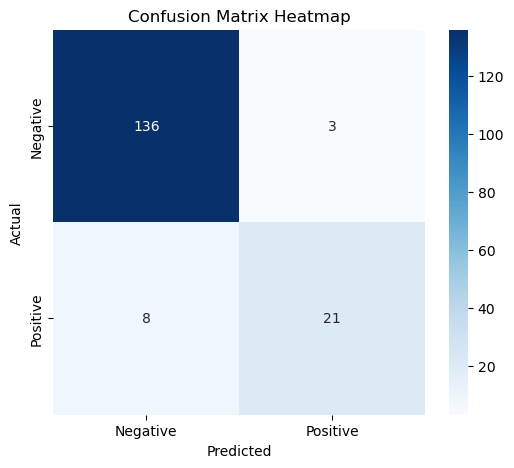

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming y_true and y_pred are already defined
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()
